In [ ]:
!pip -q install transformers torch torchvision pillow matplotlib

In [ ]:
import torch
import matplotlib.pyplot as plt

from PIL import Image
from google.colab import files
from transformers import CLIPProcessor, CLIPModel

In [ ]:
if torch.cuda.is_available():
    print("GPU is available")
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("GPU is NOT available (CPU mode)")

GPU is available
GPU name: Tesla T4


Saving laptop.jpeg to laptop.jpeg
image size: (960, 720)


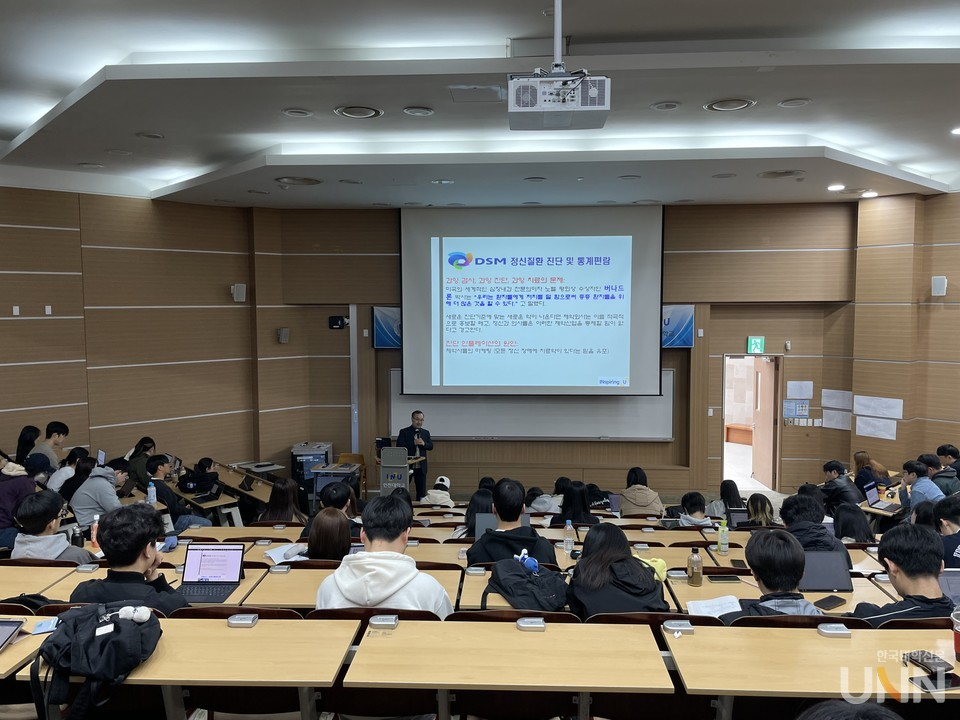

In [ ]:
uploaded = files.upload()

image_path = list(uploaded.keys())[0]
image = Image.open(image_path).convert("RGB")

print("image size:", image.size)
image

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [ ]:
model_name = "openai/clip-vit-base-patch32"

processor = CLIPProcessor.from_pretrained(model_name)
model = CLIPModel.from_pretrained(model_name).to(device)

print("CLIP loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP loaded.


In [ ]:
candidate_labels = [
    "a laptop",
    "a tablet",
    "a desktop computer",
    "a phone",
    "a projector screen",
    "a classroom"
]

In [ ]:
inputs = processor(
    text=candidate_labels,
    images=image,
    return_tensors="pt",
    padding=True
).to(device)

with torch.no_grad():
    outputs = model(**inputs)

logits_per_image = outputs.logits_per_image
probs = logits_per_image.softmax(dim=1).cpu().numpy()[0]

In [ ]:
print("CLIP classification results:\n")

for label, prob in zip(candidate_labels, probs):
    print(f"{label}: {prob:.4f}")

best_idx = probs.argmax()
best_label = candidate_labels[best_idx]
best_score = probs[best_idx]

print("\nBest prediction:")
print(f"{best_label} (score={best_score:.4f})")

CLIP classification results:

a laptop: 0.0062
a tablet: 0.0006
a desktop computer: 0.0054
a phone: 0.0006
a projector screen: 0.5839
a classroom: 0.4033

Best prediction:
a projector screen (score=0.5839)


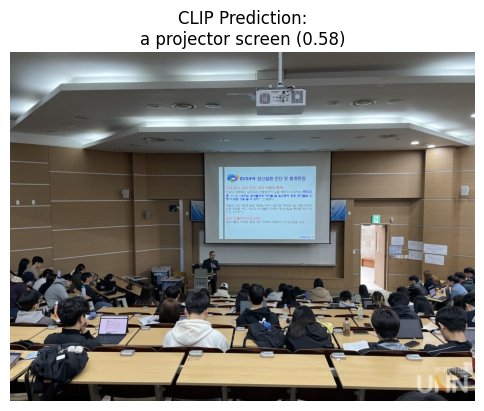

In [ ]:
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title(f"CLIP Prediction:\n{best_label} ({best_score:.2f})")
plt.axis("off")
plt.show()